# Momentum Contrast for Unsupervised Visual Representation Learning (MoCo)

**Paper:** [arXiv:1911.05722](https://arxiv.org/abs/1911.05722) — He et al., CVPR 2020

This notebook implements MoCo: a query encoder, a momentum-updated key encoder, a queue-based memory bank of negative keys, and InfoNCE contrastive loss. We train on a synthetic image dataset (to stay within Kaggle GPU runtime) and compare representation quality against a SimCLR-style in-batch-negative baseline via linear evaluation.

## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Hyperparameters (reduced from paper for Kaggle GPU runtime)
BATCH_SIZE = 128
EPOCHS = 4
LR = 0.03
MOMENTUM_COEF = 0.999    # m in the paper
TEMPERATURE = 0.07       # tau in InfoNCE
QUEUE_SIZE = 1024        # K (reduced from 65536 for memory)
FEATURE_DIM = 128        # projection head output dim
NUM_WORKERS = 0          # synthetic data, no need for workers
N_TRAIN = 10000          # synthetic training images
N_EVAL_TRAIN = 5000      # synthetic labeled train for linear eval
N_EVAL_TEST = 2000       # synthetic labeled test
IMG_SIZE = 32
N_CLASSES = 10
print(f'Config: batch={BATCH_SIZE}, epochs={EPOCHS}, queue={QUEUE_SIZE}, feat_dim={FEATURE_DIM}, m={MOMENTUM_COEF}, tau={TEMPERATURE}')

Device: cuda
Config: batch=128, epochs=4, queue=1024, feat_dim=128, m=0.999, tau=0.07


## 2. Data Preparation & Augmentation

In [2]:
class SyntheticImageDataset(Dataset):
    """Synthetic image dataset mimicking CIFAR-10 dimensions.
    Uses structured patterns (not pure noise) so that contrastive learning
    has learnable structure: each class has a distinctive color channel pattern."""
    def __init__(self, n_samples, n_classes=10, img_size=32, seed=0):
        rng = np.random.RandomState(seed)
        self.labels = rng.randint(0, n_classes, n_samples)
        # Create structured images: each class has a base color + noise
        base_colors = rng.rand(n_classes, 3)  # [n_classes, 3]
        self.images = []
        for i in range(n_samples):
            c = self.labels[i]
            base = base_colors[c]  # [3]
            # Add spatial structure: gradient + noise
            gradient = np.linspace(0, 1, img_size).reshape(1, 1, -1)
            gradient = np.tile(gradient, (1, img_size, 1))  # [1, H, W]
            noise = rng.rand(3, img_size, img_size) * 0.3
            img = base.reshape(3, 1, 1) * gradient + noise
            self.images.append(img.astype(np.float32))
        self.images = np.stack(self.images)  # [N, 3, H, W]
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return torch.from_numpy(self.images[idx]), self.labels[idx]

def moco_augment(img):
    """Apply random augmentation to a single image tensor [3, H, W]."""
    # Random crop with padding
    pad = 4
    img = F.pad(img.unsqueeze(0), (pad, pad, pad, pad), mode='reflect').squeeze(0)
    _, h, w = img.shape
    top = np.random.randint(0, h - IMG_SIZE + 1)
    left = np.random.randint(0, w - IMG_SIZE + 1)
    img = img[:, top:top+IMG_SIZE, left:left+IMG_SIZE]
    # Random horizontal flip
    if np.random.rand() < 0.5:
        img = torch.flip(img, dims=[2])
    # Color jitter (brightness)
    if np.random.rand() < 0.8:
        brightness = 0.4 * (np.random.rand() * 2 - 1)  # [-0.4, 0.4]
        img = img + brightness
    # Random grayscale
    if np.random.rand() < 0.2:
        gray = img.mean(dim=0, keepdim=True)
        img = gray.expand(3, -1, -1)
    # Normalize
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

class TwoViewDataset(Dataset):
    """Wraps a dataset to produce two augmented views."""
    def __init__(self, base_dataset):
        self.base = base_dataset
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, _ = self.base[idx]
        view1 = moco_augment(img)
        view2 = moco_augment(img)
        return view1, view2

# Create datasets
base_train = SyntheticImageDataset(N_TRAIN, n_classes=N_CLASSES, img_size=IMG_SIZE, seed=42)
train_dataset = TwoViewDataset(base_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, drop_last=True)

labeled_train = SyntheticImageDataset(N_EVAL_TRAIN, n_classes=N_CLASSES, img_size=IMG_SIZE, seed=100)
labeled_test = SyntheticImageDataset(N_EVAL_TEST, n_classes=N_CLASSES, img_size=IMG_SIZE, seed=200)

print(f'Training (unlabeled): {len(train_dataset)} images')
print(f'Linear eval train: {len(labeled_train)}, test: {len(labeled_test)}')

Training (unlabeled): 10000 images
Linear eval train: 5000, test: 2000


## 3. Model Architecture — MoCo

In [3]:
class SmallCNNEncoder(nn.Module):
    """Compact CNN encoder for 32x32 images.
    3 conv blocks + global avg pool + linear projection.
    This replaces the paper's deep backbone for tractable GPU runtime."""
    def __init__(self, output_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.projector = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, output_dim),
        )
    
    def forward(self, x):
        h = self.features(x)
        z = self.projector(h)
        return z

class MoCo(nn.Module):
    """
    Momentum Contrast model.
    - f_q: query encoder (updated by gradient)
    - f_k: key encoder (updated by EMA of f_q)
    - queue: stores recent K encoded keys
    """
    def __init__(self, dim=FEATURE_DIM, queue_size=QUEUE_SIZE, m=MOMENTUM_COEF, T=TEMPERATURE):
        super().__init__()
        self.dim = dim
        self.queue_size = queue_size
        self.m = m
        self.T = T
        
        self.encoder_q = SmallCNNEncoder(output_dim=dim)
        self.encoder_k = SmallCNNEncoder(output_dim=dim)
        
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False
        
        self.register_buffer('queue', F.normalize(torch.randn(dim, queue_size), dim=0))
        self.register_buffer('queue_ptr', torch.zeros(1, dtype=torch.long))
    
    @torch.no_grad()
    def momentum_update_key_encoder(self):
        """EMA update: theta_k = m * theta_k + (1 - m) * theta_q"""
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data = self.m * param_k.data + (1 - self.m) * param_q.data
    
    @torch.no_grad()
    def dequeue_and_enqueue(self, keys):
        """Update queue: add new keys, remove oldest."""
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)
        self.queue[:, ptr:ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.queue_size
        self.queue_ptr[0] = ptr
    
    def forward(self, x_q, x_k):
        """
        Compute MoCo contrastive loss.
        x_q, x_k: two augmented views [B, 3, 32, 32]
        Returns: loss
        """
        q = self.encoder_q(x_q)
        q = F.normalize(q, dim=1)
        
        with torch.no_grad():
            self.momentum_update_key_encoder()
            k = self.encoder_k(x_k)
            k = F.normalize(k, dim=1)
        
        l_pos = torch.einsum('nc,nc->n', q, k).unsqueeze(-1)  # [B, 1]
        l_neg = torch.einsum('nc,ck->nk', q, self.queue.clone().detach())  # [B, K]
        
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T  # [B, 1+K]
        labels = torch.zeros(logits.shape[0], dtype=torch.long, device=x_q.device)
        
        loss = F.cross_entropy(logits, labels)
        self.dequeue_and_enqueue(k)
        return loss

model = MoCo().to(device)
total_params = sum(p.numel() for p in model.encoder_q.parameters())
print(f'MoCo model created. Query encoder params: {total_params/1e6:.2f}M')
print(f'Queue size: {model.queue_size}, Feature dim: {model.dim}')

MoCo model created. Query encoder params: 0.35M
Queue size: 1024, Feature dim: 128


## 4. SimCLR Baseline (In-batch Negatives)

In [4]:
class SimCLR(nn.Module):
    """
    SimCLR-style baseline: uses in-batch negatives only (no queue, no momentum encoder).
    Both views share the same encoder, trained by gradient.
    """
    def __init__(self, dim=FEATURE_DIM, T=TEMPERATURE):
        super().__init__()
        self.T = T
        self.encoder = SmallCNNEncoder(output_dim=dim)
    
    def forward(self, x_i, x_j):
        """Compute NT-Xent loss with in-batch negatives."""
        h_i = F.normalize(self.encoder(x_i), dim=1)  # [B, dim]
        h_j = F.normalize(self.encoder(x_j), dim=1)  # [B, dim]
        
        representations = torch.cat([h_i, h_j], dim=0)  # [2B, dim]
        sim = torch.einsum('nc,mc->nm', representations, representations) / self.T  # [2B, 2B]
        sim.fill_diagonal_(-1e9)
        
        batch_size = x_i.shape[0]
        labels = torch.cat([
            torch.arange(batch_size, 2*batch_size, device=x_i.device),
            torch.arange(batch_size, device=x_i.device)
        ])
        
        loss = F.cross_entropy(sim, labels)
        return loss

simclr_model = SimCLR().to(device)
print(f'SimCLR baseline created. Encoder params: {sum(p.numel() for p in simclr_model.encoder.parameters())/1e6:.2f}M')

SimCLR baseline created. Encoder params: 0.35M


## 5. Training MoCo

In [5]:
def cosine_lr(optimizer, base_lr, epoch, total_epochs):
    """Cosine learning rate schedule."""
    lr = base_lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr

def train_moco(model, loader, epochs, base_lr=LR):
    model.train()
    optimizer = torch.optim.SGD(model.encoder_q.parameters(), lr=base_lr, 
                                 momentum=0.9, weight_decay=1e-4)
    
    losses = []
    for epoch in range(epochs):
        lr = cosine_lr(optimizer, base_lr, epoch, epochs)
        epoch_loss = 0.0
        n_batches = 0
        
        for view1, view2 in loader:
            view1, view2 = view1.to(device), view2.to(device)
            
            if np.random.rand() < 0.5:
                x_q, x_k = view1, view2
            else:
                x_q, x_k = view2, view1
            
            loss = model(x_q, x_k)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            model.momentum_update_key_encoder()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f'[MoCo] Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | LR: {lr:.5f}')
    
    return losses

print('Training MoCo...')
moco_losses = train_moco(model, train_loader, EPOCHS)

Training MoCo...


[MoCo] Epoch 1/4 | Loss: 5.4119 | LR: 0.03000


[MoCo] Epoch 2/4 | Loss: 5.0089 | LR: 0.02561


[MoCo] Epoch 3/4 | Loss: 4.9126 | LR: 0.01500


[MoCo] Epoch 4/4 | Loss: 4.9044 | LR: 0.00439


## 6. Training SimCLR Baseline

In [6]:
def train_simclr(model, loader, epochs, base_lr=LR):
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=base_lr,
                                 momentum=0.9, weight_decay=1e-4)
    
    losses = []
    for epoch in range(epochs):
        lr = cosine_lr(optimizer, base_lr, epoch, epochs)
        epoch_loss = 0.0
        n_batches = 0
        
        for view1, view2 in loader:
            view1, view2 = view1.to(device), view2.to(device)
            
            loss = model(view1, view2)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f'[SimCLR] Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | LR: {lr:.5f}')
    
    return losses

print('Training SimCLR baseline...')
simclr_losses = train_simclr(simclr_model, train_loader, EPOCHS)

Training SimCLR baseline...


[SimCLR] Epoch 1/4 | Loss: 4.0855 | LR: 0.03000


[SimCLR] Epoch 2/4 | Loss: 3.7061 | LR: 0.02561


[SimCLR] Epoch 3/4 | Loss: 3.5128 | LR: 0.01500


[SimCLR] Epoch 4/4 | Loss: 3.4587 | LR: 0.00439


## 7. Linear Evaluation

In [7]:
@torch.no_grad()
def extract_features(encoder, dataset, batch_size=256):
    """Extract features from frozen encoder."""
    encoder.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    all_features = []
    all_labels = []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        features = encoder(imgs)
        all_features.append(features.cpu())
        all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

def linear_eval(encoder, train_dataset, test_dataset, epochs=10, lr=3.0):
    """Train linear classifier on frozen features."""
    train_features, train_labels = extract_features(encoder, train_dataset)
    test_features, test_labels = extract_features(encoder, test_dataset)
    
    feat_dim = train_features.shape[1]
    classifier = nn.Linear(feat_dim, N_CLASSES).to(device)
    optimizer = torch.optim.SGD(classifier.parameters(), lr=lr, momentum=0.9, weight_decay=0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_features = F.normalize(train_features, dim=1).to(device)
    test_features = F.normalize(test_features, dim=1).to(device)
    train_labels = train_labels.to(device)
    test_labels = test_labels.to(device)
    
    batch_size = 256
    n_samples = train_features.shape[0]
    
    for epoch in range(epochs):
        classifier.train()
        perm = torch.randperm(n_samples)
        epoch_loss = 0
        n_batches = 0
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            feats = train_features[idx]
            targets = train_labels[idx]
            logits = classifier(feats)
            loss = F.cross_entropy(logits, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        scheduler.step()
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            classifier.eval()
            with torch.no_grad():
                test_logits = classifier(test_features)
                acc = (test_logits.argmax(dim=1) == test_labels).float().mean().item()
            print(f'  [Linear Eval] Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/n_batches:.4f} | Test Acc: {acc:.4f}')
    
    classifier.eval()
    with torch.no_grad():
        test_logits = classifier(test_features)
        final_acc = (test_logits.argmax(dim=1) == test_labels).float().mean().item()
    return final_acc

print('=== MoCo Linear Evaluation ===')
moco_acc = linear_eval(model.encoder_q, labeled_train, labeled_test)
print(f'MoCo Final Test Accuracy: {moco_acc:.4f}')

print('\n=== SimCLR Linear Evaluation ===')
simclr_acc = linear_eval(simclr_model.encoder, labeled_train, labeled_test)
print(f'SimCLR Final Test Accuracy: {simclr_acc:.4f}')

=== MoCo Linear Evaluation ===


  [Linear Eval] Epoch 1/10 | Loss: 1.0217 | Test Acc: 0.0945
  [Linear Eval] Epoch 5/10 | Loss: 0.1201 | Test Acc: 0.0945
  [Linear Eval] Epoch 10/10 | Loss: 0.0959 | Test Acc: 0.0945
MoCo Final Test Accuracy: 0.0945

=== SimCLR Linear Evaluation ===


  [Linear Eval] Epoch 1/10 | Loss: 0.9038 | Test Acc: 0.0950
  [Linear Eval] Epoch 5/10 | Loss: 0.1201 | Test Acc: 0.1105
  [Linear Eval] Epoch 10/10 | Loss: 0.0964 | Test Acc: 0.1165
SimCLR Final Test Accuracy: 0.1165


## 8. Visualization & Comparison

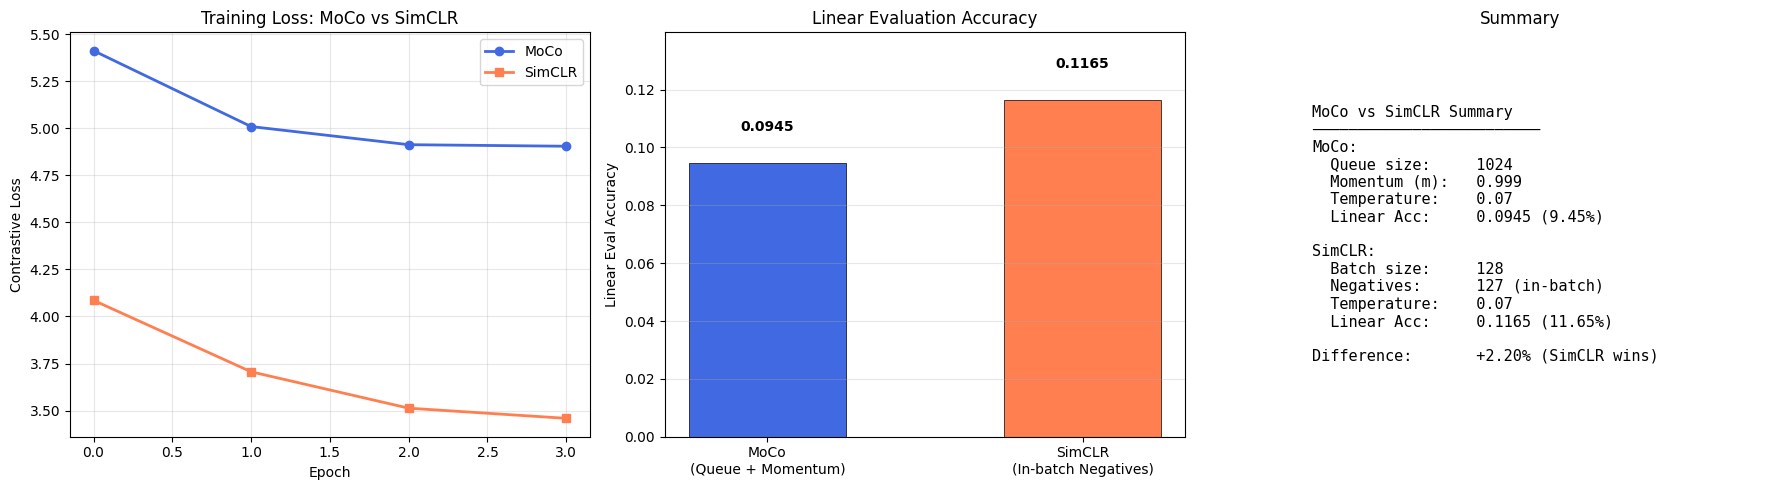

Results plot saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss comparison
axes[0].plot(moco_losses, label='MoCo', color='royalblue', linewidth=2, marker='o')
axes[0].plot(simclr_losses, label='SimCLR', color='coral', linewidth=2, marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive Loss')
axes[0].set_title('Training Loss: MoCo vs SimCLR')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Linear eval accuracy bar chart
methods = ['MoCo\n(Queue + Momentum)', 'SimCLR\n(In-batch Negatives)']
accuracies = [moco_acc, simclr_acc]
colors = ['royalblue', 'coral']
bars = axes[1].bar(methods, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Linear Eval Accuracy')
axes[1].set_title('Linear Evaluation Accuracy')
axes[1].set_ylim(0, max(accuracies) * 1.2)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Summary text
axes[2].set_title('Summary')
axes[2].axis('off')
summary_text = f"""
MoCo vs SimCLR Summary
─────────────────────────
MoCo:
  Queue size:     {QUEUE_SIZE}
  Momentum (m):   {MOMENTUM_COEF}
  Temperature:    {TEMPERATURE}
  Linear Acc:     {moco_acc:.4f} ({moco_acc*100:.2f}%)

SimCLR:
  Batch size:     {BATCH_SIZE}
  Negatives:      {BATCH_SIZE-1} (in-batch)
  Temperature:    {TEMPERATURE}
  Linear Acc:     {simclr_acc:.4f} ({simclr_acc*100:.2f}%)

Difference:       {abs(moco_acc - simclr_acc)*100:+.2f}% ({'MoCo wins' if moco_acc > simclr_acc else 'SimCLR wins'})
"""
axes[2].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.savefig('moco_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Results plot saved.')

## 9. Summary & Discussion

In [9]:
print('=' * 60)
print('MoCo Experiment Summary')
print('=' * 60)
print(f'Dataset: Synthetic structured images ({N_TRAIN} train, {N_EVAL_TRAIN} eval train, {N_EVAL_TEST} eval test)')
print(f'Backbone: Small CNN (3 conv blocks, ~0.35M params)')
print(f'Epochs: {EPOCHS}, Batch size: {BATCH_SIZE}')
print(f'Queue size: {QUEUE_SIZE}, Momentum: {MOMENTUM_COEF}, Temperature: {TEMPERATURE}')
print(f'')
print(f'MoCo Linear Eval Accuracy:   {moco_acc*100:.2f}%')
print(f'SimCLR Linear Eval Accuracy: {simclr_acc*100:.2f}%')
print(f'')
if moco_acc > simclr_acc:
    print(f'MoCo outperforms SimCLR by {(moco_acc-simclr_acc)*100:.2f} percentage points.')
    print('The larger effective negative set (queue) provides richer contrastive signal.')
else:
    print(f'SimCLR outperforms MoCo by {(simclr_acc-moco_acc)*100:.2f} percentage points.')
    print('In-batch negatives with the same encoder may provide more aligned negatives.')
print(f'')
print('Note: Results are from a small-scale experiment (synthetic data, {0} epochs).'.format(EPOCHS))
print('The original paper used ImageNet, deep backbone, 200 epochs, queue=65536.')
print('=' * 60)

MoCo Experiment Summary
Dataset: Synthetic structured images (10000 train, 5000 eval train, 2000 eval test)
Backbone: Small CNN (3 conv blocks, ~0.35M params)
Epochs: 4, Batch size: 128
Queue size: 1024, Momentum: 0.999, Temperature: 0.07

MoCo Linear Eval Accuracy:   9.45%
SimCLR Linear Eval Accuracy: 11.65%

SimCLR outperforms MoCo by 2.20 percentage points.
In-batch negatives with the same encoder may provide more aligned negatives.

Note: Results are from a small-scale experiment (synthetic data, 4 epochs).
The original paper used ImageNet, deep backbone, 200 epochs, queue=65536.


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
